     AGE  FEMALE  LOS  RACE  TOTCHG  APRDRG
0     17       1    2   1.0    2660     560
1     17       0    2   1.0    1689     753
2     17       1    7   1.0   20060     930
3     17       1    1   1.0     736     758
4     17       1    1   1.0    1194     754
..   ...     ...  ...   ...     ...     ...
495    0       1    6   1.0    5881     636
496    0       1    2   1.0    1171     640
497    0       1    2   1.0    1171     640
498    0       1    2   1.0    1086     640
499    0       0    4   1.0    4931     640

[500 rows x 6 columns]
[[ 17   1   2 560]
 [ 17   0   2 753]
 [ 17   1   7 930]
 ...
 [  0   1   2 640]
 [  0   1   2 640]
 [  0   0   4 640]]
     AGE  FEMALE  LOS  RACE    TOTCHG  APRDRG
0     17       1    2   1.0  0.044467     560
1     17       0    2   1.0  0.024177     753
2     17       1    7   1.0  0.408058     930
3     17       1    1   1.0  0.004263     758
4     17       1    1   1.0  0.013833     754
..   ...     ...  ...   ...       ...     ...
495   

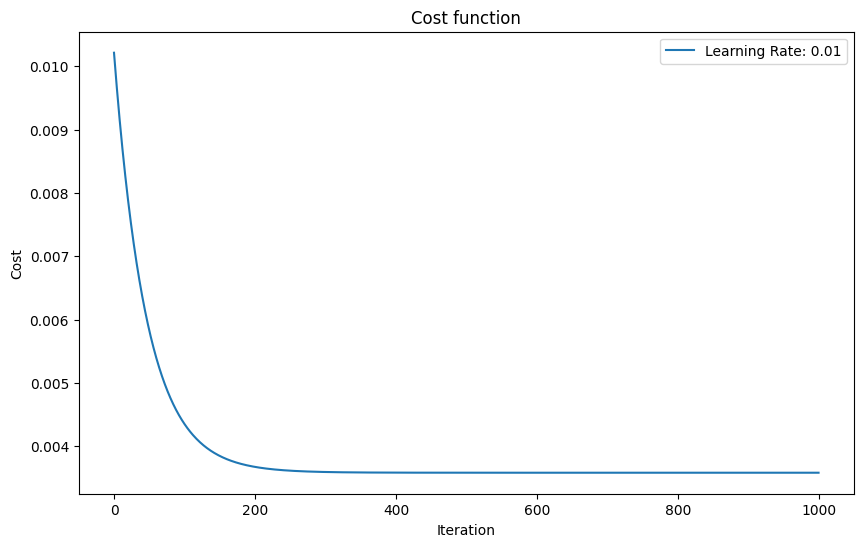

Mean Squared Error: 0.0004133287539644472
R2 value: 0.7740748343545274
count    500.000000
mean       0.046857
std        0.081252
min        0.000000
25%        0.014298
50%        0.020990
75%        0.041755
max        1.000000
Name: TOTCHG, dtype: float64


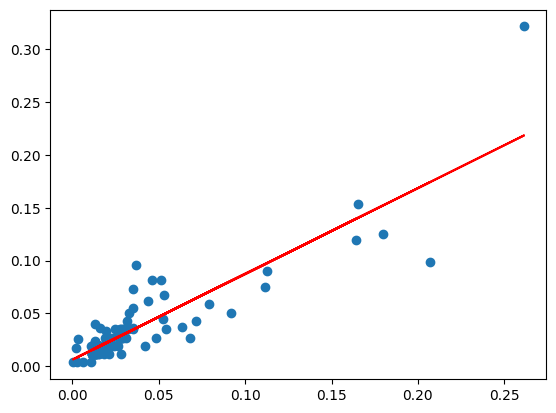

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# getting the dataset
path='C:\\Users\\samik\\Downloads\\linear_regression_dataset (1).csv'
data = pd.read_csv(path)
print(data)

# Features and Target Variable
X = data.drop(['TOTCHG','RACE'], axis=1).values  # Features //independent variables
print(X) #dropped  race and totchg
data['TOTCHG'] = (data['TOTCHG'] - data['TOTCHG'].min()) / (data['TOTCHG'].max() - data['TOTCHG'].min())#normalising  the data for min error to bring it to the same scale as other variables
y = data['TOTCHG'].values  # Target variable//dependent variables
print(data)
print("independent\n")
print(X)
print("dependent\n")
print(y)


#Z-score normalising the features/independent variavbles= mean =0 and std deviation=1
X_mean = X.mean(axis=0)
print("mean\n")
print(X_mean)
X_std=np.std(X,axis=0)
print("standard\n")
print(X_std)
X_normalized = (X - X_mean) / X_std
print("normalised\n")
print(X_normalized)
# calculating bias
X_b = np.c_[np.ones(X_normalized.shape[0]), X_normalized]
# splitting data into train and test
split_index = int(0.8 * len(X_b))
X_train, X_test = X_b[:split_index], X_b[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
# gradient descent
def gradient_descent(X, y, learning_rate, iterations):
    m = len(y)
    weights = np.zeros(X.shape[1])
    cost_history = []

    for _ in range(iterations):
        predictions = X @ weights
        errors = predictions - y
        cost =np.mean((errors) ** 2)
        cost_history.append(cost)
    # Update the weights 
        weights -= (learning_rate / m) * (X.T @ errors)
    
    return weights, cost_history

weights, cost_function = gradient_descent(X_train, y_train, 0.01,1000)
plt.figure(figsize=(10, 6))
plt.plot(cost_function, label=f'Learning Rate: 0.01')
plt.title('Cost function')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.show()

# predictions
def predict(X, weights):
    return X @ weights
y_pred = predict(X_test, weights)

#plotting the best fit line graph
plt.scatter(y_test,y_pred)
best_fit_coefficients = np.polyfit(y_test, y_pred, 1)  # 1 means linear fit

# Generate the line using these coefficients
best_fit_line = np.poly1d(best_fit_coefficients)

# Plot the best fit line
plt.plot(y_test, best_fit_line(y_test), color='red', label='Best Fit Line')
# Evaluating performance
mse = np.mean((y_test - y_pred) ** 2)
print('Mean Squared Error:',mse)
def r2_value(y_test, y_pred):
    ss_total=np.sum((y_test -np.mean(y_test))** 2)
    ss_residual=np.sum((y_test - y_pred)** 2)
    return 1-(ss_residual/ss_total)
r2=r2_value(y_test, y_pred)
print("R2 value:", r2)
print(data['TOTCHG'].describe())

















